In [9]:
import os
import polars as pl

file_path = os.path.join(
    os.path.dirname(os.getcwd()),
    "weather_data",
    "data",
    "nyc-tmy-2023.csv",
    # "FNL.tsv",
)

df = pl.read_csv(
    file_path,
    # separator="\t",
    # has_header=False,
    # ignore_errors=True,
    skip_rows=2,
    # new_columns=["Station", "Time", "Temperature", "Wind Direction", "Wind Speed"],
)

print(df)

# df.group_by(
#     [
#         "Year",
#         "Month",
#         # "Day",
#     ],
#     maintain_order=True,
# ).agg(pl.col("Temperature").max().alias("Max Temp"))

shape: (8_760, 10)
┌──────┬───────┬─────┬──────┬───┬───────────────────┬────────────────┬────────────┬──────────┐
│ Year ┆ Month ┆ Day ┆ Hour ┆ … ┆ Relative Humidity ┆ Wind Direction ┆ Wind Speed ┆ Pressure │
│ ---  ┆ ---   ┆ --- ┆ ---  ┆   ┆ ---               ┆ ---            ┆ ---        ┆ ---      │
│ i64  ┆ i64   ┆ i64 ┆ i64  ┆   ┆ f64               ┆ i64            ┆ f64        ┆ i64      │
╞══════╪═══════╪═════╪══════╪═══╪═══════════════════╪════════════════╪════════════╪══════════╡
│ 2022 ┆ 1     ┆ 1   ┆ 0    ┆ … ┆ 98.88             ┆ 210            ┆ 1.5        ┆ 1011     │
│ 2022 ┆ 1     ┆ 1   ┆ 1    ┆ … ┆ 98.94             ┆ 200            ┆ 1.4        ┆ 1011     │
│ 2022 ┆ 1     ┆ 1   ┆ 2    ┆ … ┆ 99.42             ┆ 185            ┆ 1.4        ┆ 1010     │
│ 2022 ┆ 1     ┆ 1   ┆ 3    ┆ … ┆ 99.15             ┆ 169            ┆ 1.4        ┆ 1010     │
│ 2022 ┆ 1     ┆ 1   ┆ 4    ┆ … ┆ 98.8              ┆ 164            ┆ 1.5        ┆ 1009     │
│ …    ┆ …     ┆ …   ┆ …    ┆ …

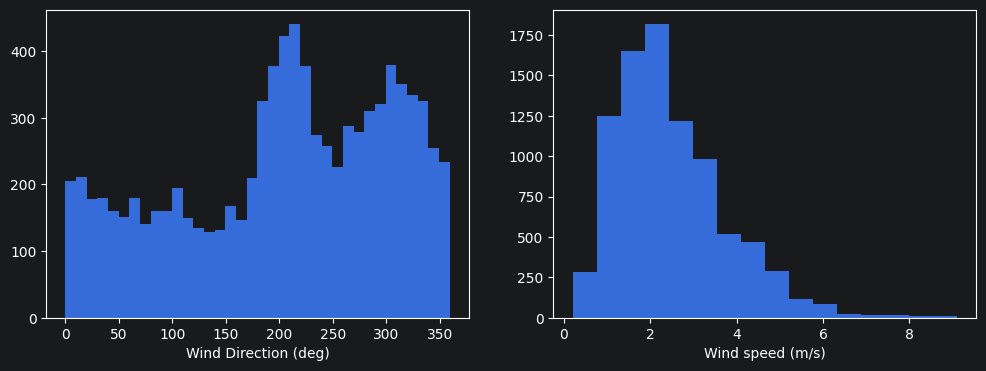

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(
    x=df["Wind Direction"],
    bins=36,
)
ax[0].set_xlabel("Wind Direction (deg)")
ax[0].set_ylabel = "Count"

ax[1].hist(
    x=df["Wind Speed"],
    bins=16,
)
ax[1].set_xlabel("Wind speed (m/s)")


plt.show()

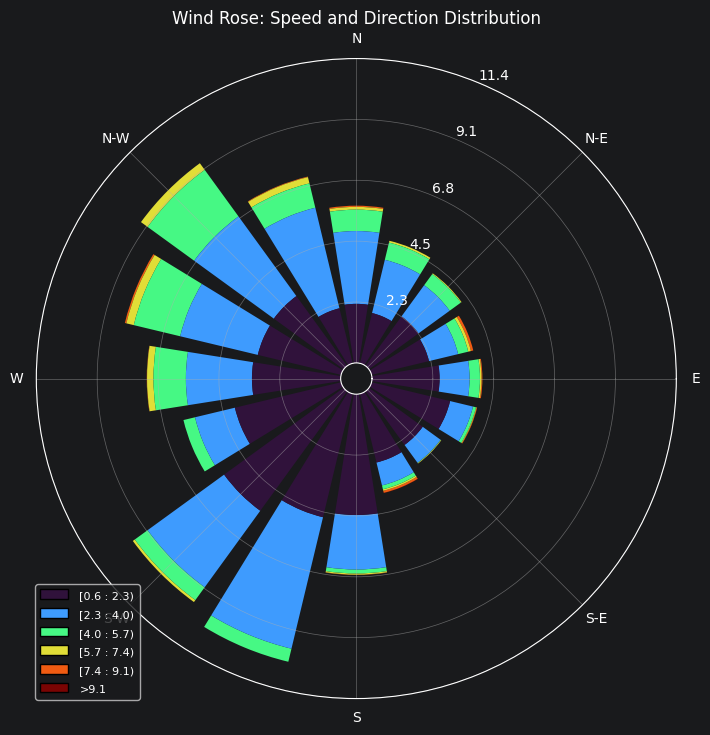

In [33]:
from windrose import WindroseAxes
import matplotlib as mpl

# from matplotlib import cm

# windrose works best with numpy arrays
wd = df["Wind Direction"].to_numpy()
ws = df["Wind Speed"].to_numpy()

# 2. Initialize the figure
fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

# 3. Create the wind rose
ax.bar(
    wd,
    ws,
    normed=True,
    # bins=[2, 4, 8, 16, 32],
    cmap=mpl.cm.turbo,
    nsector=16,
    calm_limit=0.5,
)


# 4. Add styling and legend
ax.set_legend()
plt.title("Wind Rose: Speed and Direction Distribution")
plt.show()

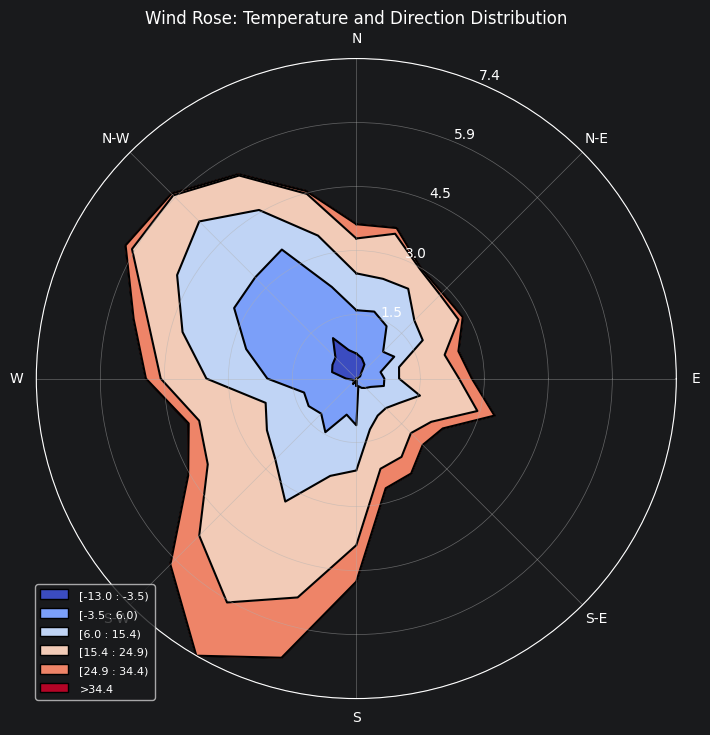

In [34]:
# add data to make thermal windrose
temp = df["Temperature"].to_numpy()

# 2. Initialize the figure
fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

# 3. Create the wind rose
nsector = 24  # 15 deg steps


ax.contourf(
    wd,
    temp,
    normed=True,
    # bins=bins,
    cmap=cm.coolwarm,  # pyright: ignore[reportAttributeAccessIssue]
    nsector=nsector,
)
ax.contour(
    wd,
    temp,
    normed=True,
    # bins=bins,
    colors="black",
    nsector=nsector,
)


# 4. Add styling and legend
ax.set_legend()
plt.title("Wind Rose: Temperature and Direction Distribution")
plt.show()